# Summary - Bayesian Machine Learning

## Philosophical Foundations and Bayes’ Theorem

### Interpretations of probability

**Frequentist definition**:
Probability of event $E$ is the *long-run relative frequency* of $E$ in infinitely many repetitions of the same experiment. Statements are about data, not parameters.[^1][^2]

- $P(E)$ is defined via an idealized limit of repetitions.
- You cannot assign probabilities to *fixed but unknown* parameters; only to outcomes of random experiments.
- Example: “Probability that a fair die shows 6 is $1/6$” = long-run fraction of 6s.

**Bayesian definition**:
Probability is a *subjective degree of belief* about events or parameters, given current knowledge.[^2][^1]

- $P(E)$ quantifies how plausible you think $E$ is.
- You can assign probabilities to *parameters*, hypotheses, or one-off events (e.g. “probability this patient has cancer”, “probability the theory is true”).
- Different observers with different prior knowledge can have different probabilities.

**Key philosophical contrast**:[^1][^2]

- Frequentist: uncertainty is in the *world* (randomness of experiments).
- Bayesian: uncertainty is in the *head* of the observer (state of information).


### Sampling vs. inference

Slides and exam clearly distinguish:[^3][^2][^1]

- **Sampling (forward problem)**: Assume parameter is known, ask:
“If $p$ is the probability of success, what is $P(Y = k \mid p)$?”

Example:
Number of heads in 10 tosses with known $p$ ~ Binomial($n=10, p$).
- **Inference (inverse problem)**: Assume data observed, parameter unknown, ask:
“Given I observed $k$ heads in 10 tosses, what do I believe about $p$?”
    - Frequentist: estimate single “best” value (e.g. MLE $\hat p = k/n$).
    - Bayesian: derive a *posterior distribution* over $p$: $p(p \mid \text{data})$.[^4][^2]


### Bayes’ theorem and roles of likelihood

**Bayes’ theorem (discrete)**:[^4][^1]

$$
P(A \mid B) = \frac{P(B\mid A)P(A)}{P(B)}.
$$

**Belief-updater view**:[^4][^1]

$$
\underbrace{P(A\mid d)}_{\text{posterior}}
\propto
\underbrace{P(d\mid A)}_{\text{likelihood}}
\times
\underbrace{P(A)}_{\text{prior}}.
$$

- **Prior**: beliefs before data.
- **Likelihood**: how plausible data are under different parameter values.
- **Posterior**: updated beliefs after data.

**Likelihood in both schools**:[^3][^2][^4]

- Frequentist:
    - Likelihood $L(\theta) = p(d \mid \theta)$ used to find *point estimates* (e.g. MLE).
    - Parameters treated as fixed unknowns.
- Bayesian:
    - Likelihood enters Bayes theorem to produce $p(\theta \mid d)$.
    - Parameters treated as random variables.


### When Bayesian methods are preferable

Typical situations where a Bayesian approach is more appropriate:[^2][^3][^1][^4]

- **Small sample sizes / rare events**: frequentist asymptotics unreliable.
- **Strong prior information** available (expert opinion, previous studies) and should be integrated.
- **Need full uncertainty quantification** (posterior distributions, credible intervals) rather than point estimates or p-values.
- **Complex hierarchical or graphical models**, where likelihood-based methods get complicated but Bayesian methods remain conceptually coherent.


### The computational curse of Bayesian statistics

Core difficulty: the **evidence** (marginal likelihood) is an often intractable integral:[^2][^4]

$$
p(d) = \int p(d\mid \theta)p(\theta)\,d\theta.
$$

- In simple conjugate families this integral is analytic.
- In realistic models (many parameters, non-Gaussian likelihoods), high‑dimensional integrals are impossible to compute in closed form.[^2]
- This computational curse motivates **Markov Chain Monte Carlo (MCMC)** and **Variational Inference**.[^5][^2]

## Conjugate Families and Continuous Inference

### From discrete to continuous: Beta–Binomial

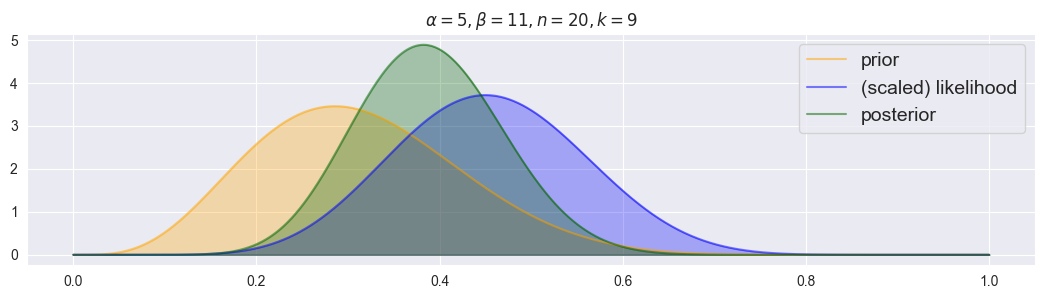

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_beta_binomial( alpha, beta, n, k, figsize=(13,3) ):
    # create figure
    plt.figure( figsize=figsize )

    # numeric evaluation range for pi
    pi_range = np.linspace(0, 1, 1000)

    # prior
    prior = [stats.beta.pdf(pi, a=alpha, b=beta) for pi in pi_range]
    plt.plot( pi_range, prior, alpha=0.5, label="prior", c="orange" )
    plt.fill_between( pi_range, prior, alpha=0.3, color="orange" )

    # scaled likelihood
    likelihood = [stats.binom.pmf(n=n, k=k, p=pi) for pi in pi_range]
    likelihood /= np.sum( likelihood ) * (pi_range[1]-pi_range[0])
    plt.plot( pi_range, likelihood, alpha=0.5, label="(scaled) likelihood", c="blue" )
    plt.fill_between( pi_range, likelihood, alpha=0.3, color="blue" )

    # posterior
    posterior = [stats.beta.pdf(pi, a=alpha+k, b=beta+n-k) for pi in pi_range]
    plt.plot( pi_range, posterior, alpha=0.5, label="posterior", color="darkgreen" )
    plt.fill_between( pi_range, posterior, alpha=0.3, color="darkgreen" )

    # enable legend and set descriptive title
    plt.legend( fontsize=14 )
    plt.title( "$\\alpha = {}, \\beta={}, n={}, k={}$".format(alpha, beta, n, k) )

plot_beta_binomial(alpha=5, beta=11, n=20, k=9)

**Likelihood** (Binomial counts):

<Axes: >

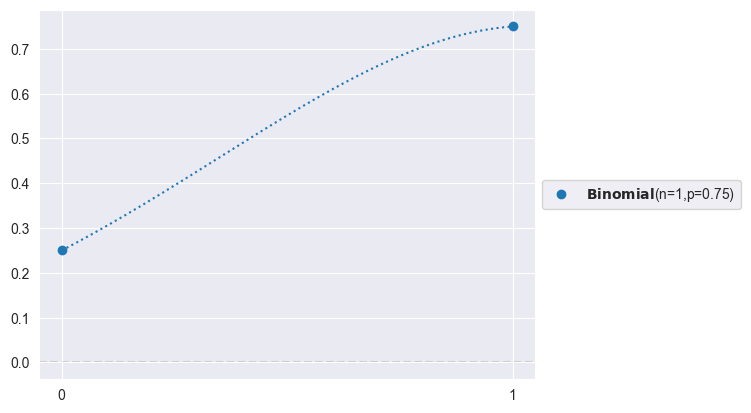

In [10]:
import preliz as pz
pz.Binomial(n=1, p=0.75).plot_pdf()

$$
Y \sim \text{Binomial}(n, \pi),\quad P(Y=k\mid \pi)=\binom{n}{k}\pi^k(1-\pi)^{n-k}.
$$

**Prior** (continuous distribution over $\pi \in [0,1]$): Beta($\alpha,\beta$):

<Axes: >

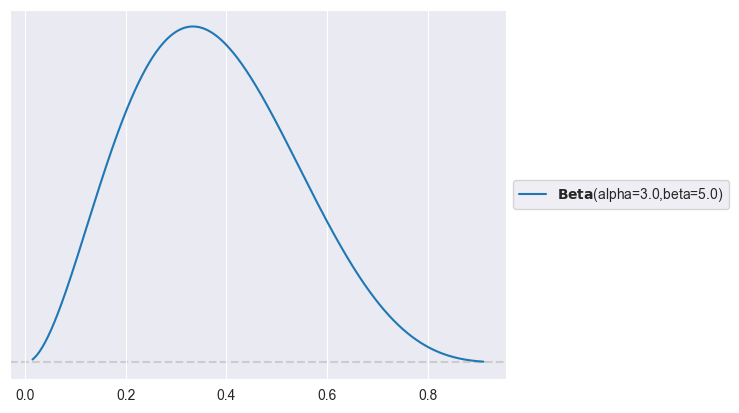

In [11]:
import preliz as pz
pz.Beta(alpha=3, beta=5).plot_pdf()



$$
p(\pi) = \text{Beta}(\pi \mid \alpha,\beta)
\propto \pi^{\alpha-1}(1-\pi)^{\beta-1}.
$$

**Posterior** after observing $k$ successes out of $n$:

$$
\pi \mid Y=k ~\sim \text{Beta}(\alpha + k,\; \beta + n - k).
$$

**Key properties**:

- Prior “pseudo-counts”: $\alpha-1$ successes, $\beta-1$ failures.
- Posterior mean:

$$
\mathbb E[\pi\mid d] = \frac{\alpha+k}{\alpha+\beta+n}.
$$

- With more data, likelihood dominates; with little data, prior dominates.
- Order of data does not matter; only sufficient statistics $(n,k)$.





### Other important conjugate families

From slides:

**Poisson–Gamma**: counts with unknown rate $\lambda$:

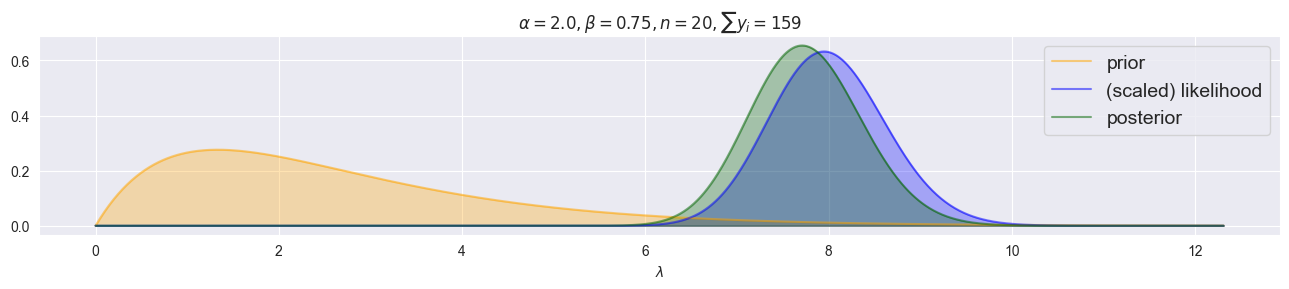

In [15]:
def plot_gamma_poisson(alpha, beta, y, figsize=(13, 3)):
    y = np.asarray(y)
    n = len(y)
    sum_y = y.sum()

    # Posterior hyperparameters
    alpha_post = alpha + sum_y
    beta_post  = beta + n

    # Choose a range for lambda using high quantiles of prior and posterior
    # (robust and adaptive to parameter scale)
    # scipy.stats.gamma uses shape 'a' and scale = 1/rate
    scale_prior = 1.0 / beta
    scale_post  = 1.0 / beta_post

    lam_max = max(
        stats.gamma.ppf(0.999, a=alpha,      scale=scale_prior),
        stats.gamma.ppf(0.999, a=alpha_post, scale=scale_post)
    )
    lam_range = np.linspace(0, lam_max, 1000)

    plt.figure(figsize=figsize)

    # Prior
    prior = stats.gamma.pdf(lam_range, a=alpha, scale=scale_prior)
    plt.plot(lam_range, prior, alpha=0.5, label="prior", c="orange")
    plt.fill_between(lam_range, prior, alpha=0.3, color="orange")

    # Likelihood as function of lambda: L(λ) = ∏_i Pois(y_i | λ)
    # Use log-likelihood for numerical stability
    log_like = np.zeros_like(lam_range)
    for yi in y:
        log_like += stats.poisson.logpmf(yi, mu=lam_range)
    likelihood = np.exp(log_like)

    # Numerically normalize likelihood over lam_range so it behaves like a pdf on this grid
    norm_const = np.trapz(likelihood, lam_range)
    if norm_const > 0:
        likelihood /= norm_const
    plt.plot(lam_range, likelihood, alpha=0.5, label="(scaled) likelihood", c="blue")
    plt.fill_between(lam_range, likelihood, alpha=0.3, color="blue")

    # Posterior
    posterior = stats.gamma.pdf(lam_range, a=alpha_post, scale=scale_post)
    plt.plot(lam_range, posterior, alpha=0.5, label="posterior", color="darkgreen")
    plt.fill_between(lam_range, posterior, alpha=0.3, color="darkgreen")

    # Legend and title
    plt.legend(fontsize=14)
    plt.xlabel(r"$\lambda$")
    plt.title(r"$\alpha = {}, \beta = {}, n = {}, \sum y_i = {}$"
              .format(alpha, beta, n, int(sum_y)))
    plt.tight_layout()
    plt.show()

plot_gamma_poisson(alpha=2.0, beta=0.75, y=[7, 8, 3, 7, 11, 7, 9, 19, 7, 15, 9, 5, 12, 3, 7, 6, 5, 3, 11, 5])


- Likelihood: $Y\sim\text{Poisson}(\lambda)$.
- Prior: $\lambda \sim \text{Gamma}(\alpha,\beta)$.
- Posterior: $\lambda\mid d \sim \text{Gamma}(\alpha + \sum y_i, \beta + n)$

**Normal–Normal** (known variance):

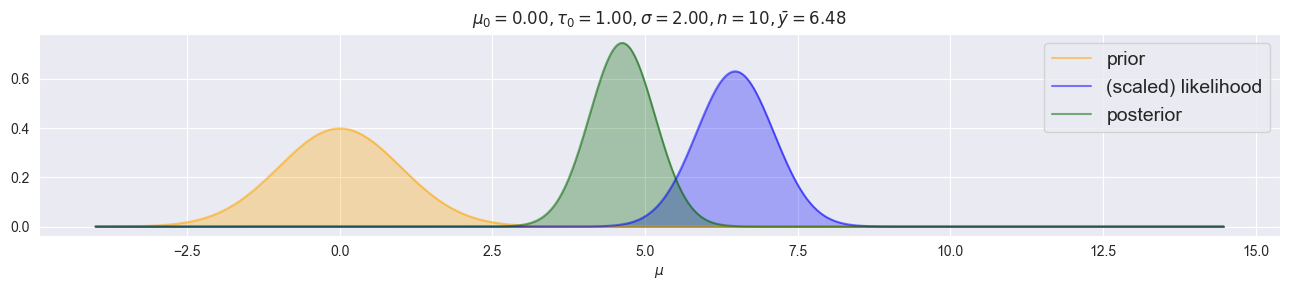

In [14]:
def plot_normal_normal(mu0, tau0, sigma, y, figsize=(13, 3)):
    y = np.asarray(y)
    n = len(y)
    ybar = y.mean()

    # Posterior variance and mean
    tau_n2 = 1.0 / (n / sigma**2 + 1.0 / tau0**2)
    mu_n = tau_n2 * (n * ybar / sigma**2 + mu0 / tau0**2)
    tau_n = np.sqrt(tau_n2)

    # Choose a plotting range for mu around data and prior
    mu_min = min(ybar - 4 * sigma, mu0 - 4 * tau0, mu_n - 4 * tau_n)
    mu_max = max(ybar + 4 * sigma, mu0 + 4 * tau0, mu_n + 4 * tau_n)
    mu_range = np.linspace(mu_min, mu_max, 1000)

    plt.figure(figsize=figsize)

    # Prior over mu
    prior = stats.norm.pdf(mu_range, loc=mu0, scale=tau0)
    plt.plot(mu_range, prior, alpha=0.5, label="prior", c="orange")
    plt.fill_between(mu_range, prior, alpha=0.3, color="orange")

    # Likelihood as function of mu (up to constant)
    # Equivalent to N(mu | ybar, sigma^2/n)
    like_unnorm = stats.norm.pdf(mu_range, loc=ybar, scale=sigma / np.sqrt(n))
    # Numerically normalize to integrate ~1 on this grid
    norm_const = np.trapz(like_unnorm, mu_range)
    likelihood = like_unnorm / norm_const if norm_const > 0 else like_unnorm

    plt.plot(mu_range, likelihood, alpha=0.5, label="(scaled) likelihood", c="blue")
    plt.fill_between(mu_range, likelihood, alpha=0.3, color="blue")

    # Posterior over mu
    posterior = stats.norm.pdf(mu_range, loc=mu_n, scale=tau_n)
    plt.plot(mu_range, posterior, alpha=0.5, label="posterior", color="darkgreen")
    plt.fill_between(mu_range, posterior, alpha=0.3, color="darkgreen")

    # Legend and title
    plt.legend(fontsize=14)
    plt.xlabel(r"$\mu$")
    plt.title(
        r"$\mu_0 = {:.2f}, \tau_0 = {:.2f}, \sigma = {:.2f}, n = {}, \bar y = {:.2f}$"
        .format(mu0, tau0, sigma, n, ybar)
    )
    plt.tight_layout()
    plt.show()

np.random.seed(0)
plot_normal_normal(mu0=0.0, tau0=1.0, sigma=2.0, y=np.random.normal(loc=5.0, scale=2.0, size=10))


- Likelihood: $Y_i\mid \mu \sim \mathcal N(\mu,\sigma^2)$.
- Prior: $\mu \sim \mathcal N(\mu_0,\tau_0^2)$.
- Posterior: $\mu\mid d \sim \mathcal N(\mu_n,\tau_n^2)$ with closed‑form updates.

General lesson: conjugate families are pedagogically useful to understand **how priors and data trade off**, even when you later use MCMC instead of formulas.

## Markov Chain Monte Carlo and the Metropolis Algorithm

### Why MCMC?

Goal: obtain samples from $p(\theta\mid d)$ when no closed form is available.
MCMC constructs a Markov chain whose stationary distribution is the posterior.

### Metropolis algorithm (random-walk variant)

  0%|          | 0/1000 [00:00<?, ?it/s]

Rhat: 1.0


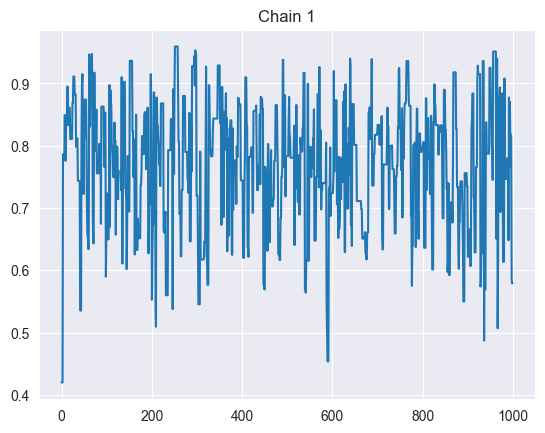

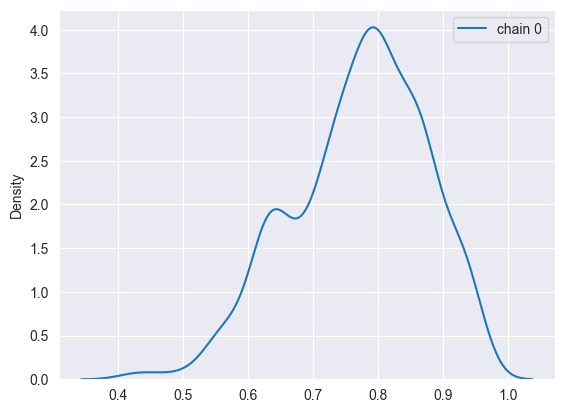

In [59]:
from scipy import stats
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

def propose_jump(pi, sigma):
    return stats.norm.rvs( loc=pi, scale=sigma )

def decide(pi, pi2, alpha, beta, n, k, debug=False):
    # evaluate prior and likelihood
    prior1 = stats.beta.pdf( pi, alpha, beta )
    prior2 = stats.beta.pdf( pi2, alpha, beta )
    likelihood1 = stats.binom.pmf( n=n, k=k, p=pi )
    likelihood2 = stats.binom.pmf( n=n, k=k, p=pi2 )

    # define alpha
    alpha = min(1, prior2/prior1 * likelihood2/likelihood1)
    if debug: print("pi = {:.5f}, pi2 = {:.5f}, alpha = {:.5f}".format(pi, pi2, alpha))

    # jump decision
    p = np.random.rand()
    if p<=alpha and 0 < pi2 < 1:
        return pi2
    else:
        return pi

def metropolis_chain(n_steps, alpha, beta, n, k, sigma):
    # initialize
    pi = np.random.rand()
    chain = []

    # create chain
    for i in tqdm( range( n_steps ) ):
        pi2 = propose_jump( pi, sigma )
        pi = decide( pi, pi2, alpha, beta, n, k )
        chain.append( pi )

    return chain

def metropolis( n_chains, n_steps, alpha, beta, n, k, sigma ):
    res = [metropolis_chain( n_steps, alpha, beta, n, k, sigma ) for i in range( n_chains)]
    return np.array(res).T # to have chains in columns

def trace_plots(sim):
    for i in range( sim.shape[1] ):
        plt.figure()
        plt.plot( sim[:,i] )
        plt.title("Chain {}".format(i+1))

def density_plots( sim ):
    plt.figure()
    for i in range( sim.shape[1] ):
        sns.kdeplot( sim[:,i], label="chain {}".format(i) )
    plt.legend()

def rhat( sim ):
    total_var = np.var( sim.flatten() )
    individual_var = np.var( sim, axis=0 )
    rhat = np.sqrt( total_var / np.mean(individual_var) )
    return rhat

sim = metropolis(n_chains=1, n_steps=1000, alpha=5, beta=2, n=10, k=8, sigma=0.2)

trace_plots(sim)
density_plots(sim)
print(f"Rhat: {rhat(sim)}")

For target density $\pi(\theta) = p(\theta\mid d)$, symmetric proposal $q(\theta' \mid \theta)$, the Metropolis steps are:[^3][^2]

1. **Initialize** $\theta^{(0)}$ (e.g. some reasonable value).
2. For iterations $t = 0,1,\dots$:

3. **Propose** new state
$\theta' \sim q(\theta' \mid \theta^{(t)})$.
E.g. random walk: $q = \mathcal N(\theta^{(t)}, \sigma_{\text{prop}}^2)$.
4. **Compute acceptance probability**

$$
\alpha = \min\left\{1,\;\frac{\pi(\theta')}{\pi(\theta^{(t)})}\right\}
= \min\left\{1,\;\frac{p(d\mid \theta')p(\theta')}{p(d\mid \theta^{(t)})p(\theta^{(t)})}\right\}.
$$

(Proposal cancels out because it is symmetric.)
5. **Accept or reject**:
        - Draw $u \sim \text{Uniform}(0,1)$.
        - If $u < \alpha$, set $\theta^{(t+1)}=\theta'$ (move).
        - Else set $\theta^{(t+1)}=\theta^{(t)}$ (stay).
1. After burn‑in and thinning, use remaining samples as approximate draws from the posterior.

**Proposal distribution**: the distribution from which proposed new parameters are drawn ($q(\theta' \mid \theta)$). Choice of its scale strongly affects mixing and acceptance rate.

### MCMC with PyMC

In [40]:
import pymc as pm
import arviz as az
import numpy as np

# Data: k successes out of n trials
n = 40
k = 26

with pm.Model() as model:
    # Prior on probability pi
    pi = pm.Beta("pi", alpha=1.0, beta=1.0)  # flat prior

    # Likelihood
    y = pm.Binomial("y", n=n, p=pi, observed=k)

    # Sample with NUTS (HMC variant; more efficient than plain Metropolis)
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 0 seconds.


### Diagnosing convergence and mixing

Key visual and numeric diagnostics:

**Trace plots:** Plot each chain’s sampled values over iterations

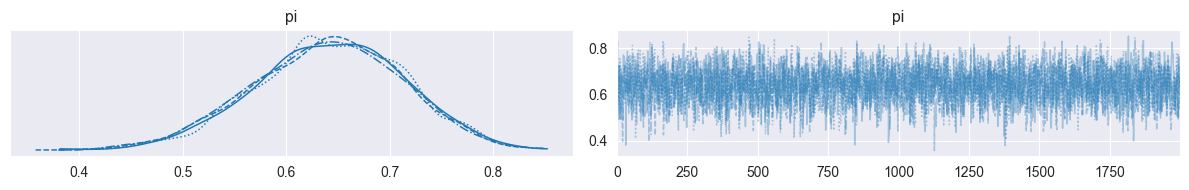

In [41]:
az.plot_trace(trace, kind='trace')
plt.tight_layout()
plt.show()

- What to look for:
  - Chains explore the same region (“fuzzy caterpillars”)
  - No systematic upward or downward drift.
  - No chains stuck in a narrow band.
  - Different chains overlap well.

**Marginal density plots:** Posterior histograms or kernel density estimates for each chain separately

- What to look for:
  - Distributions from all chains almost perfectly overlap.
  - No multi‑modal behavior unique to one chain.

**Autocorrelation plots:** Autocorrelation function (ACF) of each chain as a function of lag

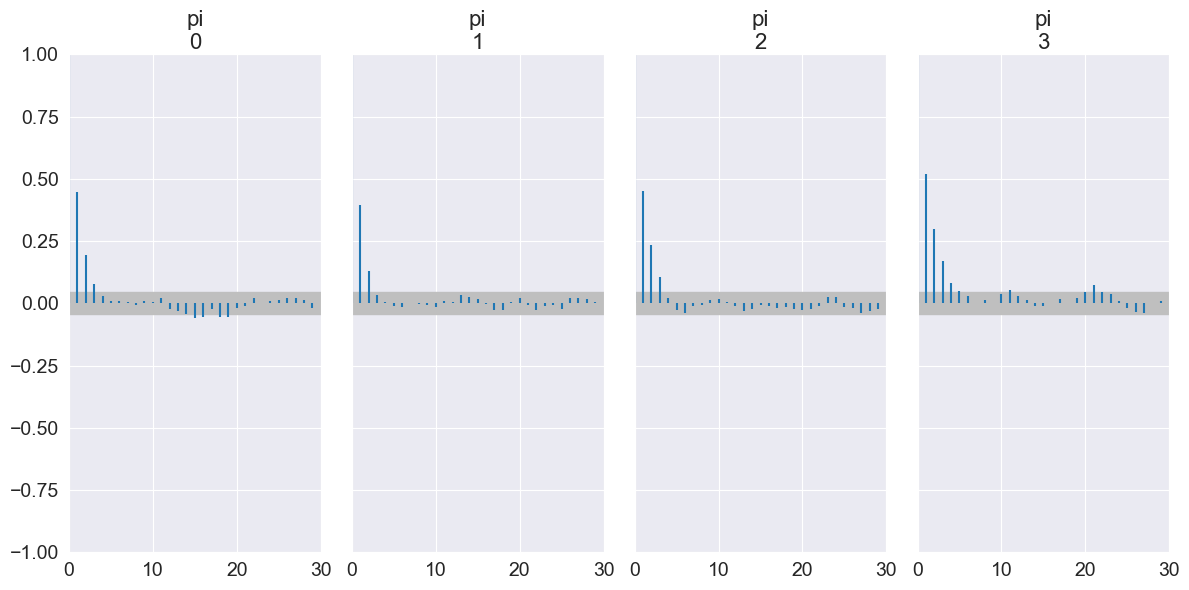

In [42]:
az.plot_autocorr(trace, max_lag=30, figsize=(12, 6))
plt.tight_layout()
plt.show()

- What to look for:
  - Autocorrelation decays quickly with lag.
  - Very slow decay or persistent high correlation → poor mixing and low effective sample size.

**Rank plots / rank bars:** For each parameter, pool all samples from all chains, compute their ranks, then see how ranks are distributed per chain (as in ArviZ’s rank plots)

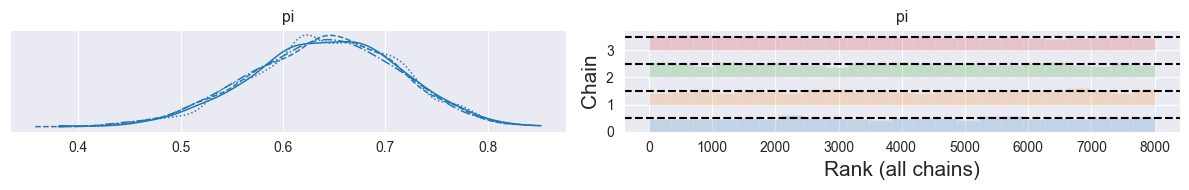

In [43]:
az.plot_trace(trace, kind='rank_bars')
plt.tight_layout()
plt.show()

- What to look for:
  - Ranks within each chain are roughly uniformly distributed.
  - All chains show similar, flat-ish rank patterns.
  - Strong deviations (U‑shape, spikes, or clearly different patterns per chain) indicate non‑convergence or poor mixing.

**$\hat R$ (R‑hat, Gelman–Rubin statistic):** Compares between‑chain variance to within‑chain variance

In [44]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
pi,0.641,0.073,0.505,0.775,0.001,0.001,3041.0,4233.0,1.0


- What to look for:
  - $\hat R \approx 1.00$ (e.g. < 1.01–1.05) → chains have likely converged.
  - $\hat R > 1.05$ → potential non‑convergence; need more draws, better initialization, or reparameterization.

**ESS (effective sample size):** Estimates how many *independent* draws your autocorrelated chain is equivalent to

In [46]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
pi,0.641,0.073,0.505,0.775,0.001,0.001,3041.0,4233.0,1.0


- What to look for:
  - ESS large relative to the number of draws, giving stable posterior summaries → **Rule of thumb: ESS / N > 10%**
  - Very small ESS (especially compared to total draws) → strong autocorrelation, poor mixing, unreliable summaries.
- `ess_bulk` (Bulk ESS): Use this to assess reliability of posterior means, medians, and central credible intervals.
  - Estimates the effective sample size for the central part of the distribution (around the median/mean).
  - Interpretation: Higher is better. If `ess_bulk` is very small relative to the total number of draws, the chain is autocorrelated or has poor mixing in the center of the distribution.
- `ess_tail` (Tail ESS): Use this to assess reliability of HDI/credible interval bounds and tail probabilities.
  - Estimates the effective sample size specifically for the tails of the distribution (extreme quantiles, typically 5th and 95th percentiles).
  - Interpretation: Higher is better. Can be substantially lower than `ess_bulk` if the tails are poorly explored.

**Interpretation of $\hat R$**:

- $\hat R \approx 1$: chains have converged to same target distribution.
- $\hat R > 1.05$: potential non‑convergence; increase iterations or reparameterize.

**Typical pathologies**:

- Chain stuck in a region → proposal step too small or multimodality.
- Very high autocorrelation → inefficient exploration.
- Different chains sampling different modes → need better initialization or samplers.

For Metropolis specifically, problematic trace plots often indicate:

- Proposal variance too small (tiny steps, high acceptance, poor exploration).
- Proposal variance too large (proposals rejected, chain rarely moves).
Tunable by adjusting $\sigma_{\text{prop}}$.

## Posterior Summaries, Prediction, and Uncertainty

In [61]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# Data: k successes out of n trials
n = 40
k = 26

with pm.Model() as beta_binom_model:
    # Prior on probability pi
    pi = pm.Beta("pi", alpha=1.0, beta=1.0)  # flat prior

    # Likelihood
    y = pm.Binomial("y", n=n, p=pi, observed=k)

    # Sample posterior
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

# Posterior summary (mean, sd, HDI, mcse, ess, r_hat)
summary = az.summary(trace, var_names=["pi"], hdi_prob=0.80)
summary

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 0 seconds.


,mean,sd,hdi_10%,hdi_90%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
pi,0.641,0.073,0.552,0.738,0.001,0.001,3041.0,4233.0,1.0


### Point summaries: mean, variance, MAP

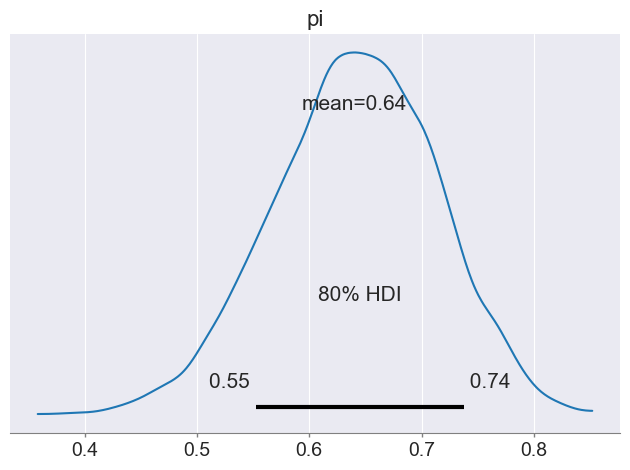

Posterior mean      = 0.6405
Posterior variance  = 0.0053
80% HDI             = [0.5524, 0.7381]


In [65]:
import numpy as np
import arviz as az

# ArviZ posterior plot: shows density + HDI interval + mean/median
az.plot_posterior(trace, hdi_prob=0.80)
plt.tight_layout()
plt.show()

# Extract samples as 1D array
pi_samples = trace.posterior["pi"].values.flatten()

# Posterior mean and variance
pi_mean = pi_samples.mean()
pi_var  = pi_samples.var(ddof=1)

# 80% HDI using ArviZ
pi_hdi = az.hdi(pi_samples, hdi_prob=0.80)

print(f"Posterior mean      = {pi_mean:.4f}")
print(f"Posterior variance  = {pi_var:.4f}")
print(f"80% HDI             = [{pi_hdi[0]:.4f}, {pi_hdi[1]:.4f}]")

Given posterior samples $\theta_1,\dots,\theta_N$:

- Posterior mean:

$$
\hat\theta_{\text{mean}} = \frac{1}{N}\sum_{i=1}^N \theta_i.
$$
- Posterior variance:

$$
\widehat{\text{Var}}(\theta) = \frac{1}{N-1}\sum_{i=1}^N(\theta_i - \hat\theta_{\text{mean}})^2.
$$
- MAP (mode): value of $\theta$ maximizing posterior density; with samples, approximate by binning and taking the peak.


### Credible intervals vs confidence intervals

**Credible interval (Bayesian)**:

- For posterior $p(\theta\mid d)$, an **80% credible interval** $[a,b]$ satisfies:

$$
P(a \le \theta \le b \mid d) = 0.8.
$$
- Direct statement about the parameter: “Given data and model, we believe with 80% plausibility that $\theta$ lies in $[a,b]$.”

**HDI (Highest Density Interval)**:

- Among all 80% intervals, choose the one where posterior density is everywhere at least as high as outside.
- Minimizes width for a given mass; by construction contains the most probable values.

**Confidence interval (frequentist)**:

- 80% CI: in 80% of repeated experiments, the interval constructed by a given procedure will contain the *fixed* true $\theta$.
- Does *not* allow the statement “$\theta$ is in this specific interval with probability 0.8”.

Exams often ask to articulate this conceptual difference precisely.

### Prediction and posterior predictive distribution

For parameter $\theta$ and new observation $y_{\text{new}}$:

$$
p(y_{\text{new}}\mid d) = \int p(y_{\text{new}}\mid \theta)\,p(\theta\mid d)\,d\theta.
$$

With posterior samples $\theta_i$:

1. For each $\theta_i$, draw $y_{\text{new},i} \sim p(y\mid \theta_i)$.
2. Empirical distribution of $\{y_{\text{new},i}\}$ approximates $p(y_{\text{new}}\mid d)$.

Example: binomial predictive for future counts:

- $Y_{\text{new},i} \sim \text{Binomial}(n_{\text{new}}, \pi_i)$, where $\pi_i$ are posterior samples of $\pi$.


### Aleatoric vs epistemic uncertainty

From predictive variance decomposition:

- **Aleatoric uncertainty**: irreducible data noise (e.g. binomial or Gaussian observation noise).
- **Epistemic uncertainty**: uncertainty about model parameters; reducible with more/better data.

For predictive distribution:

$$
\text{Var}(Y_{\text{new}}\mid d)
= \underbrace{\mathbb E_{\theta\mid d}[\text{Var}(Y_{\text{new}}\mid \theta)]}_{\text{aleatoric}}
+ \underbrace{\text{Var}_{\theta\mid d}\big(\mathbb E[Y_{\text{new}}\mid \theta]\big)}_{\text{epistemic}}.
$$

Practical implication:

- If epistemic >> aleatoric → collecting more data can meaningfully reduce predictive uncertainty.
- If aleatoric dominates → even infinite data cannot substantially reduce predictive spread (inherent randomness).

## Bayesian Hypothesis Testing

### One-sided tests

Instead of p-values, Bayesian tests compare posterior probability of hypotheses.[^6][^2]

Example (tongue-rolling):

- $H_0$: $\pi \le 0.8$.
- $H_1$: $\pi > 0.8$.

With posterior samples $\pi_i$, approximate:

$$
P(H_1\mid d) = P(\pi>0.8\mid d) \approx \frac{1}{N}\sum_{i=1}^N \mathbf 1(\pi_i>0.8).
$$

Interpretation: “We believe with 95% probability that $\pi > 0.8$.”[^2]

### Bayes factors and odds

**Prior odds** for $H_1$ vs $H_0$:

$$
\frac{P(H_1)}{P(H_0)}.
$$

**Posterior odds** after data:

$$
\frac{P(H_1\mid d)}{P(H_0\mid d)}.
$$

**Bayes factor** $BF_{10}$:[^2]

$$
BF_{10} = \frac{P(d\mid H_1)}{P(d\mid H_0)}
= \frac{\text{posterior odds}}{\text{prior odds}}.
$$

Rules of thumb (Kass \& Raftery scale) used in slides:

- 1–3: barely worth mentioning.
- 3–10: substantial.
- 10–100: strong.
- >100: decisive evidence in favour of $H_1$.[^2]


### ROPE for equivalence (two-sided)

For testing whether a parameter is *practically equal* to some value $\theta_0$, define a **ROPE** (Region of Practical Equivalence), e.g. $[\theta_0-\delta, \theta_0+\delta]$.[^2]

- $H_0$: $\theta \in [\theta_0-\delta,\theta_0+\delta]$.
- $H_1$: $\theta$ outside that interval.

From posterior samples $\theta_i$, estimate:

$$
P(H_0\mid d) \approx \frac{1}{N}\sum\mathbf 1(\theta_0-\delta \le \theta_i \le \theta_0+\delta).
$$

If most posterior mass lies inside the ROPE, you accept *practical equivalence*; otherwise, you conclude a meaningful difference.

## Model Checking, Selection, and Multivariate Distributions

### Posterior predictive checks

Procedure:[^7][^6][^2]

1. Fit model and obtain posterior samples.
2. For each posterior draw, simulate an entire *replicated* dataset from the model (posterior predictive).
3. Compare distribution of replicated data to observed data (histograms, kernel density plots, summary statistics).

If simulated data systematically differ (e.g. lower variance, wrong tail behaviour), the model is likely misspecified (e.g. wrong likelihood family).

**Example: maternity ward**:[^6]

- Poisson likelihood forced $\text{Var}(Y)=\mathbb E[Y]$; empirical data showed variance > mean (overdispersion).
- Posterior predictive showed too narrow distribution; Negative Binomial provided better fit (flexible mean and variance).


### Poisson vs Negative Binomial for counts

**Poisson**:[^6]

$$
P(Y=k\mid \lambda) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad
\mathbb E[Y]=\lambda,\; \text{Var}(Y)=\lambda.
$$

**Negative Binomial** parameterized via $(r,\lambda)$:[^6]

- Mean: $\mathbb E[K \mid r,\lambda] = \lambda$.
- Variance: $\text{Var}(K \mid r,\lambda) = \lambda(1+\lambda/r) > \lambda$.

Thus NB can model **overdispersed** counts (variance > mean).

As $r \to \infty$, NB converges to Poisson.

### Model selection criteria

From Week 5 and 6 slides:[^7][^6]

- **Fully Bayesian**: Bayes factor (based on marginal likelihood).
    - Conceptually clean, but marginal likelihood can be hard to compute.
- **Predictive criteria**:
    - RMSE, MAE (point prediction error using posterior predictive means).
    - **ELPD / LOO** (Expected Log Predictive Density with leave-one-out cross-validation).
        - Computed with PSIS-LOO, higher is better.
    - Bayesian R$^2$ for regression (see Section 7).

These criteria trade off **fit** vs **complexity**; Bayesian evidence automatically penalizes overly complex models (“built-in Occam’s razor”).[^7][^6]

### Multivariate distributions: Multinomial–Dirichlet, Multivariate Normal

**Multinomial–Dirichlet**:[^6]

- Likelihood: counts over $K$ categories, $Y\sim\text{Multinomial}(n,\boldsymbol\pi)$.
- Prior: Dirichlet$(\boldsymbol\alpha)$, $\boldsymbol\alpha=(\alpha_1,\dots,\alpha_K)$.
- Posterior: Dirichlet$(\boldsymbol\alpha + \mathbf k)$, where $k_j$ counts in category $j$.

Used for compositional data (election results, topic proportions).

**Multivariate Normal**:[^8][^6]

- $x\in\mathbb R^D$, $x\sim\mathcal N(\boldsymbol\mu,\Sigma)$ with covariance matrix $\Sigma$.
- Important properties:
    - Closed under linear transformations, addition, marginalization, conditioning.
    - Covariance controls scale and correlation; must be symmetric and positive definite.
- **LKJ prior** for correlation matrices: flexible prior on correlation structures; together with priors on standard deviations gives **LKJCov** prior for $\Sigma$.[^6]

## Bayesian Linear Regression

### Probabilistic model

For data $(x_i,y_i)$, with feature vector $x_i \in \mathbb R^D$, linear model:[^8][^7]

$$
y_i = w^\top x_i + \epsilon_i,\quad \epsilon_i\sim\mathcal N(0,\sigma_{\text{obs}}^2).
$$

- Collect into matrices: $y\in\mathbb R^N$, $X\in\mathbb R^{N\times D}$.

**Likelihood**:[^8][^7]

$$
p(y\mid X,w,\sigma_{\text{obs}}^2) = \mathcal N(y\mid Xw, \sigma_{\text{obs}}^2 I).
$$

**Prior** (Gaussian):[^8]

$$
w \sim \mathcal N(0,\Sigma_p).
$$

**Posterior over weights**:[^8]

$$
p(w\mid y) = \mathcal N(w \mid \mu, A^{-1}),
$$

with

$$
A = \frac{1}{\sigma_{\text{obs}}^2}X^\top X + \Sigma_p^{-1},\quad
\mu = \frac{1}{\sigma_{\text{obs}}^2}A^{-1} X^\top y.
$$

### Predictive distribution

For new input $x_*$:[^8]

- Latent function value:

$$
f_* = w^\top x_* \mid y \sim \mathcal N(\mu^\top x_*, x_*^\top A^{-1} x_*).
$$
- Noisy observation:

$$
y_* \mid y \sim \mathcal N(\mu^\top x_*,\; \sigma_{\text{obs}}^2 + x_*^\top A^{-1} x_*).
$$

Interpretation:

- $\sigma_{\text{obs}}^2$ = aleatoric uncertainty.
- $x_*^\top A^{-1} x_*$ = epistemic uncertainty (parameter uncertainty projected into output).


### Implementation and interpretation (PyMC/Bambi)

Slides use Bambi to fit models like:[^7]

```python
model = bmb.Model("BodyFat ~ 1 + BMI", data=data, family="gaussian")
fit   = model.fit(draws=2000, tune=2000)
```

Key diagnostics:

- Posterior summaries ($\mu,\sigma$) and HDIs for regression coefficients.
- If HDI for a coefficient excludes 0, that predictor is considered important at that credibility level.[^7]
- **Bayesian R$^2$**: posterior distribution over explained variance; gives both mean and uncertainty.[^7]
- Posterior predictive plots:
    - Line + epistemic band (parameter uncertainty).
    - Full predictive band (epistemic + aleatoric).

For exam-level questions, know:

- How to write down the model and priors.
- Interpret posterior means and HDIs.
- Distinguish epistemic vs aleatoric uncertainty in regression context.

## Gaussian Processes (GPs)

### Intuition and definition

Gaussian Processes are distributions over functions:[^5][^8]

- $f(x) \sim \mathcal{GP}(m(x), k(x,x'))$.
- For any finite set of inputs $\{x_i\}_{i=1}^N$, the vector $f = (f(x_1),\dots,f(x_N))$ is multivariate normal with mean vector $m$ and covariance matrix $K$, where $K_{ij} = k(x_i,x_j)$.[^5][^8]

In regression with noise:

$$
y_i = f(x_i) + \varepsilon_i, \quad \varepsilon_i\sim\mathcal N(0,\sigma_{\text{obs}}^2).
$$

### GP regression: predictive mean and variance

Notation (following exam and GP slides):[^5][^3]

- Training outputs $y \in \mathbb R^N$.
- Covariance matrix for training outputs (including noise):

$$
C = K_{ff} + \sigma_{\text{obs}}^2 I.
$$
- Covariances between test point and training points:

$$
k = k(x_*, X) \in \mathbb R^N.
$$
- Prior variance at test point (for $y_*$): $v = k(x_*,x_*) + \sigma_{\text{obs}}^2$.

**Predictive distribution for response $y_*$**:[^5][^3]

$$
\mathbb E[y_* \mid x_*,\text{data}] = k^\top C^{-1} y,
$$

$$
\text{Var}(y_* \mid x_*,\text{data}) = v - k^\top C^{-1}k.
$$

This matches exactly the formula given in Exam Part 1 Exercise 3.[^3]

### Connection to kernels and PSD requirement

From GP_1 and GP_3 slides:[^5][^8]

- Covariance function $k(x,x')$ must be:
    - Symmetric.
    - Positive semi-definite: for any finite set of inputs, the matrix $K$ must produce non-negative quadratic forms $z^\top K z \ge 0$.

Common kernels and hyperparameters:[^5]

- **Squared Exponential / RBF**:

$$
k(x,x') = \alpha \exp\left(-\frac{\|x-x'\|^2}{2\ell^2}\right).
$$
    - $\alpha$: output variance.
    - $\ell$: length scale (smoothness).
- **Matérn** (controls differentiability via $\nu$):
- **Rational Quadratic** (mixture over length scales).

**Exam-style point (Exercise 3)**:[^3][^5]

- If using a “kernel” that is *not* positive semi-definite (e.g. $K(x,x') = 2 + |x-x'|$), you can obtain **negative predictive variances** in the formula $v - k^\top C^{-1}k$.
- Conclusion: such a function is **not** a valid covariance function, because a covariance matrix must be positive semi-definite, implying predictive variance must be $\ge 0$.

## Bayesian Networks and Causal Inference

### Structural Causal Models (SCMs) and Bayesian Networks

SCM formalism (from BN lecture notes):[^9]

- Endogenous variables $V$: determined by structural equations.
- Exogenous variables $U$: external noise.
- Structural equations: each variable $V_i$ is a function of its parents and noise:

$$
V_i = f_i(\text{Pa}_i, U_i).
$$
- Joint distribution defined via $P(U)$ and structural equations.

A **Bayesian Network (BN)** is a DAG over variables $V$ such that joint distribution factorizes as:[^9]

$$
p(v_1,\dots,v_n) = \prod_{i=1}^n p(v_i \mid \text{Pa}_i).
$$

- Graph encodes conditional independencies.
- Each node has a Conditional Probability Table (CPT) or parameterized distribution.


### Basic graph motifs and conditional independence

Three canonical patterns:[^9]

1. **Chain (serial)**: $X \to Z \to Y$
    - $X$ and $Y$ correlated marginally.
    - Conditional independence given the middle node: $X \perp Y \mid Z$.
2. **Fork (common cause)**: $X \leftarrow Z \to Y$
    - $X$ and $Y$ correlated marginally (through common cause $Z$).
    - Conditional independence given cause: $X \perp Y \mid Z$.
3. **Collider (v‑structure)**: $X \to Z \leftarrow Y$
    - $X$ and $Y$ *independent* marginally.
    - Conditioning on collider (or its descendants) *induces dependence* (explaining away).

**Explaining away**:[^10][^9]

- In collider $X \to Z \leftarrow Y$, observing the effect $Z$ makes causes $X$ and $Y$ compete.
- Example: “Smoker” and “Covid” both cause “Hospitalization”; given hospitalization, learning that patient is a smoker reduces belief that Covid is cause, and vice versa.[^9][^3]


### Smoking–Covid example and independence

Exam graphs in Exercise 4:[^3]

- Boolean variables:
    - $S$: Smoker.
    - $H$: In hospital.
    - $C$: Covid-19 leading to hospitalization.

Tasks include:

- Decide which graph is a valid BN (must be a DAG consistent with causal story).
- Identify which graph exhibits explaining away (collider structure).
- State conditions under which $S$ and $H$ are independent (e.g. in a specific graph when conditioning on $C$ or not, depending on structure).

Key conceptual tools:

- Use BN structure to deduce (conditional) independence via intuition about chains, forks, and colliders, or formal **d‑separation**.[^9]


### Computing probabilities from joint tables

Given full joint distribution table $P(H,S,C)$ as in exam Exercise 4(d):[^3]

- **Marginal**:

$$
P(C=1) = \sum_{s,h} P(H=h, S=s, C=1).
$$
- **Conditional**:

$$
P(C=1 \mid H=1) = \frac{\sum_s P(H=1,S=s,C=1)}{\sum_{c,s}P(H=1,S=s,C=c)}.
$$

$$
P(C=1 \mid H=1, S=0) = \frac{P(H=1,S=0,C=1)}{\sum_c P(H=1,S=0,C=c)}.
$$

Exam expects you to:

- Plug numbers from table.
- Interpret results:
    - $P(C=1\mid H=1,S=0)$ vs $P(C=1\mid H=1,S=1)$: how smoking status changes probability that Covid is the cause *given* hospitalization.


### Interventions and the do‑operator

**Conditioning**: $P(Y\mid X=x)$ describes correlations in observed data; $X$ may itself be caused by other variables (confounded).[^9]

**Intervention**: $P(Y\mid \text{do}(X=x))$ describes what happens if we *force* $X$ to $x$ (surgery on the graph):

- All incoming edges into $X$ are cut.
- $X$ is set externally.
- The rest of the graph and conditional distributions remain unchanged.[^11][^9]

For a treatment $X$, outcome $Y$, and set of observed confounders $Z$ that block all backdoor paths (backdoor criterion), **adjustment formula**:[^11][^9]

$$
P(Y\mid \text{do}(X=x)) = \sum_z P(Y\mid X=x, Z=z)\,P(Z=z).
$$

Applied to smoking \& Covid:

- If $S$ (smoking) and $C$ (Covid) share some confounder, and we know the set $Z$ satisfying the backdoor criterion, we compute:

$$
P(C=1\mid \text{do}(S=s)) = \sum_z P(C=1\mid S=s, Z=z)\,P(Z=z).
$$
- In the exercise, you compute $P(C=1\mid \text{do}(S=0))$ and $P(C=1\mid \text{do}(S=1))$ from the joint distribution by:
    - Identifying appropriate adjustment set (often parent(s) of both).
    - Summing over them as in adjustment formula.[^11][^9][^3]

Conceptually, exam wants you to explain:

- How $P(C=1\mid \text{do}(S=s))$ differs from $P(C=1\mid S=s)$.
- Why interventions remove spurious associations due to confounding.

### Summary of BN/causal key points for exam

- Be able to:
    - Recognize chain, fork, collider structures and their independencies.
    - Explain explaining away in words, using Smoking–Covid–Hospital example.
    - Use chain rule and BN factorization to write joint distribution from graph.
    - Compute marginals and conditionals from a joint table.
    - Explain difference between conditioning and intervention and state adjustment formula in simple cases.

[^1]: BML_Slides_Week_01.pdf

[^2]: BML_Slides_Week_04.pdf

[^3]: Bayesian_Machine_Learning_Exam_HS2024_Part1.pdf

[^4]: BML_Slides_Week_02.pdf

[^5]: GP_3.pdf

[^6]: BML_Slides_Week_05.pdf

[^7]: BML_Slides_Week_06.pdf

[^8]: GP_1.pdf

[^9]: BML_BN_lecture_notes.pdf

[^10]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/6df4a302-9264-45e2-82db-0cc4be6f3ab1/BN_1.pdf

[^11]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/ca9efde6-5bc9-4cd5-adfa-57bc46c71248/BN_3.pdf

[^12]: Bayesian_Machine_Learning_Exam_HS2024_Part2.pdf

[^13]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/c6cb16a5-e543-4a4f-b5bc-82dbdfc6dbf8/GP_exercises_3.pdf

[^14]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/5bfb67d6-d36d-423e-a9cb-a617c2d0923e/GP_exercises_1.pdf

[^15]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/6b5c58fe-375b-4d20-989e-232fe9deb40b/BN_exercises_3.pdf

[^16]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/5ef90643-3877-4c52-aaba-a9d09720ed72/BN_exercises_2.pdf

[^17]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/da75190e-662b-4bf6-bf4c-851cacd3f6d5/BN_2.pdf

[^18]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/85039fd9-eb12-4bfa-9a7b-6408d5853e75/BN_exercises_1.pdf

[^19]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/7bea5797-910e-487a-93bf-37a8049c9ca4/BML_Exercises_Week_06.pdf

[^20]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/328a1046-5660-4ac4-9d08-0333c25f2bfa/BML_Exercises_Week_05.pdf

[^21]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/941b8853-691d-480d-8490-a6d4a26d11e6/BML_Exercises_Week_02.pdf

[^22]: https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/collection_ab020d9b-6d63-43ac-a66e-3b1b2d9e8202/3eb2160f-3354-47ca-b2bd-c20d6428995e/BML_Exercises_Week_04.pdf
